In [4]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import os

date_pull = '2024_09_07-Fall'
categ = ['faculty', 'commuter', 'accessible', 'electric']
sql_file = 'parking_data_2024-09-16.sql'


os.makedirs(date_pull, exist_ok=True)
for c in categ:
    os.makedirs(f"{date_pull}/{c}", exist_ok=True)
# Path to the SQL file


# Define an empty list to store extracted data
data = []

# Open the SQL dump file
with open(sql_file, 'r') as file:
    # Read the file line by line
    for line in file:
        # Check if the line starts with "INSERT INTO"
        if line.startswith("INSERT INTO"):
            # Extract the values from the line (assuming they are comma-separated)
            values = line.split("VALUES (")[1].rstrip(");\n").split("),(")
            # Parse each value and append it to the data list
            for value in values:
                data.append(tuple(value.strip("()").split(",")))

# Define column names
columns = ['ID', 'Zone_Id', 'Timestamp', 'Availability']
# Create DataFrame
df = pd.DataFrame(data, columns=columns)

# Convert 'Timestamp' column to DateTime format
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [5]:
df['Zone_Id'].unique()

array(['22', '13', '19', '4', '3', '27', '40', '12', '6', '2', '30', '32',
       '34', '36', '28', '39', '29', '31', '33', '35', '37', '38'],
      dtype=object)

In [3]:
# Get rid of Dates and only keep time of each entry for graphing
df['date'] = df['Timestamp'].dt.strftime('%Y-%m-%d')
df['time'] = df['Timestamp'].dt.strftime('%H:%M:%S')
df['hour'] = df['Timestamp'].dt.strftime('%H')
df['day_of_week'] = df['Timestamp'].dt.day_name()
df['Availability'] = df['Availability'].astype(float)
df['time'] = pd.to_datetime(df['time'])
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.fillna(0, inplace=True)
change = df
df.tail

<bound method NDFrame.tail of               ID Zone_Id           Timestamp  Availability        date  \
0              1      22 2024-02-20 13:06:09         729.0  2024-02-20   
1              2      13 2024-02-20 13:06:09           8.0  2024-02-20   
2              3      19 2024-02-20 13:06:09          59.0  2024-02-20   
3              4       4 2024-02-20 13:06:09          -7.0  2024-02-20   
4              5       3 2024-02-20 13:06:09          17.0  2024-02-20   
...          ...     ...                 ...           ...         ...   
8808259  8808260      31 2024-09-13 11:14:28           7.0  2024-09-13   
8808260  8808261      33 2024-09-13 11:14:28          13.0  2024-09-13   
8808261  8808262      35 2024-09-13 11:14:28          10.0  2024-09-13   
8808262  8808263      37 2024-09-13 11:14:29           7.0  2024-09-13   
8808263  8808264      38 2024-09-13 11:14:29          14.0  2024-09-13   

                       time hour day_of_week  
0       2024-09-16 13:06:09   13  

In [3]:
# Narrow to only look at proper time
df = df[df['Timestamp'] > '2024-08-17']
df

,ID,Zone_Id,Timestamp,Availability,date,time,hour,day_of_week
8037724,8037725,22,2024-08-17 00:00:31,1457.0,2024-08-17,2024-09-09 00:00:31,00,Saturday
8037725,8037726,13,2024-08-17 00:00:31,440.0,2024-08-17,2024-09-09 00:00:31,00,Saturday
8037726,8037727,19,2024-08-17 00:00:31,633.0,2024-08-17,2024-09-09 00:00:31,00,Saturday
8037727,8037728,4,2024-08-17 00:00:31,394.0,2024-08-17,2024-09-09 00:00:31,00,Saturday
8037728,8037729,27,2024-08-17 00:00:31,93.0,2024-08-17,2024-09-09 00:00:31,00,Saturday
...,...,...,...,...,...,...,...,...
8640679,8640680,31,2024-09-07 11:14:16,8.0,2024-09-07,2024-09-09 11:14:16,11,Saturday
8640680,8640681,33,2024-09-07 11:14:16,13.0,2024-09-07,2024-09-09 11:14:16,11,Saturday
8640681,8640682,35,2024-09-07 11:14:16,12.0,2024-09-07,2024-09-09 11:14:16,11,Saturday
8640682,8640683,37,2024-09-07 11:14:16,14.0,2024-09-07,2024-09-09 11:14:16,11,Saturday


In [4]:
df_weekdays = df.loc[df['day_of_week'] != 'Saturday']
df_weekdays = df.loc[df['day_of_week'] != 'Sunday']
df_weekdays

,ID,Zone_Id,Timestamp,Availability,date,time,hour,day_of_week
8037724,8037725,22,2024-08-17 00:00:31,1457.0,2024-08-17,2024-09-09 00:00:31,00,Saturday
8037725,8037726,13,2024-08-17 00:00:31,440.0,2024-08-17,2024-09-09 00:00:31,00,Saturday
8037726,8037727,19,2024-08-17 00:00:31,633.0,2024-08-17,2024-09-09 00:00:31,00,Saturday
8037727,8037728,4,2024-08-17 00:00:31,394.0,2024-08-17,2024-09-09 00:00:31,00,Saturday
8037728,8037729,27,2024-08-17 00:00:31,93.0,2024-08-17,2024-09-09 00:00:31,00,Saturday
...,...,...,...,...,...,...,...,...
8640679,8640680,31,2024-09-07 11:14:16,8.0,2024-09-07,2024-09-09 11:14:16,11,Saturday
8640680,8640681,33,2024-09-07 11:14:16,13.0,2024-09-07,2024-09-09 11:14:16,11,Saturday
8640681,8640682,35,2024-09-07 11:14:16,12.0,2024-09-07,2024-09-09 11:14:16,11,Saturday
8640682,8640683,37,2024-09-07 11:14:16,14.0,2024-09-07,2024-09-09 11:14:16,11,Saturday


In [5]:
df['Deck'] = ''
df.loc[(df['Zone_Id'] == '30'), 'Deck'] = 'Ballard'
df.loc[(df['Zone_Id'] == '32'), 'Deck'] = 'Champions'
df.loc[(df['Zone_Id'] == '34'), 'Deck'] = 'Chesapeake'
df.loc[(df['Zone_Id'] == '36'), 'Deck'] = 'Grace'
df.loc[(df['Zone_Id'] == '28'), 'Deck'] = 'Mason'
df.loc[(df['Zone_Id'] == '39'), 'Deck'] = 'Warsaw'

df.loc[(df['Zone_Id'] == '29'), 'Deck'] = 'Ballard'
df.loc[(df['Zone_Id'] == '31'), 'Deck'] = 'Champions'
df.loc[(df['Zone_Id'] == '33'), 'Deck'] = 'Chesapeake'
df.loc[(df['Zone_Id'] == '35'), 'Deck'] = 'Grace'
df.loc[(df['Zone_Id'] == '37'), 'Deck'] = 'Mason'
df.loc[(df['Zone_Id'] == '38'), 'Deck'] = 'Warsaw'

df.loc[(df['Zone_Id'] == '27'), 'Deck'] = 'Ballard'
df.loc[(df['Zone_Id'] == '40'), 'Deck'] = 'Champions'
df.loc[(df['Zone_Id'] == '6'), 'Deck'] = 'Grace'
df.loc[(df['Zone_Id'] == '12'), 'Deck'] = 'Mason'
df.loc[(df['Zone_Id'] == '2'), 'Deck'] = 'Warsaw'

df.loc[(df['Zone_Id'] == '22'), 'Deck'] = 'Ballard'
df.loc[(df['Zone_Id'] == '13'), 'Deck'] = 'Champions'
df.loc[(df['Zone_Id'] == '19'), 'Deck'] = 'Chesapeake'
df.loc[(df['Zone_Id'] == '4'), 'Deck'] = 'Grace'
df.loc[(df['Zone_Id'] == '3'), 'Deck'] = 'Warsaw'

c:\Users\jacob\miniconda3\envs\myenv8\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
c:\Users\jacob\miniconda3\envs\myenv8\lib\site-packages\pandas\core\indexing.py:1817: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)


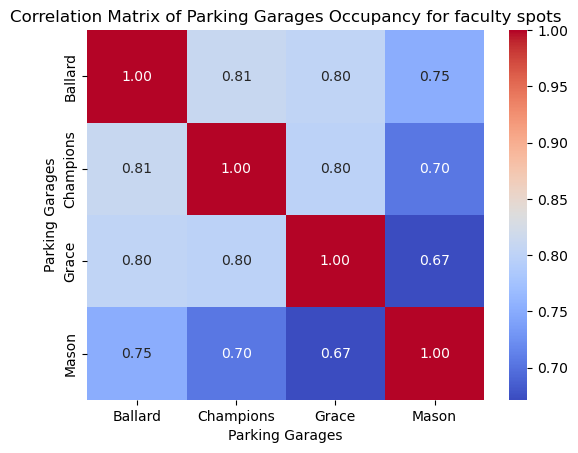

Clustered parking garages faculty:
      Garage  Cluster
0    Ballard        0
1  Champions        2
2      Grace        0
3      Mason        1


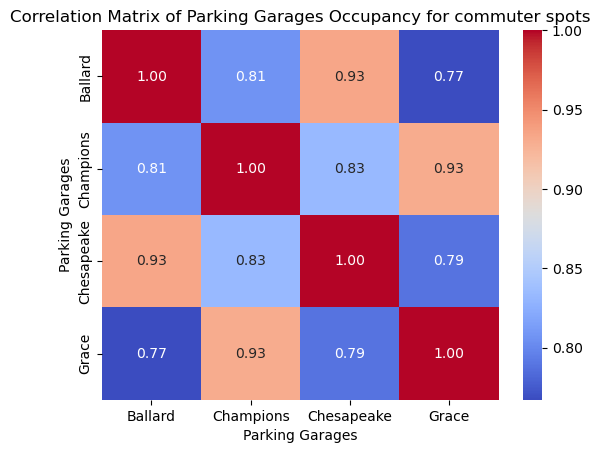

Clustered parking garages commuter:
       Garage  Cluster
0     Ballard        0
1   Champions        1
2  Chesapeake        1
3       Grace        2


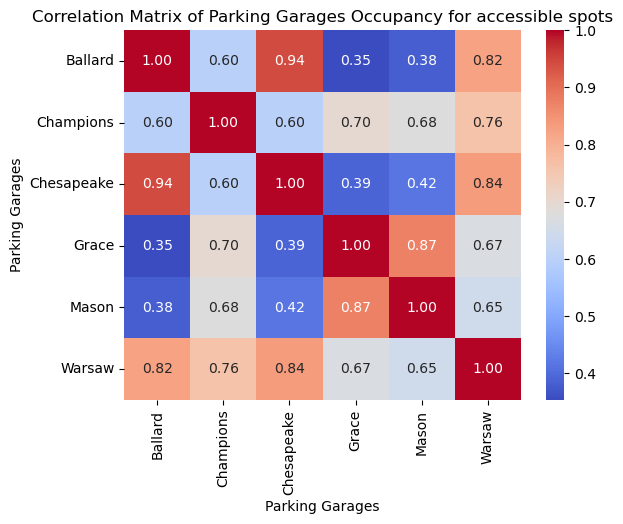

Clustered parking garages accessible:
       Garage  Cluster
0     Ballard        0
1   Champions        2
2  Chesapeake        0
3       Grace        1
4       Mason        1
5      Warsaw        0


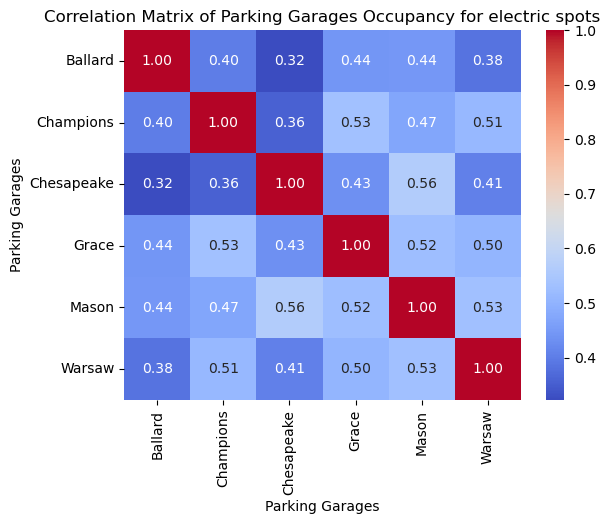

Clustered parking garages electric:
       Garage  Cluster
0     Ballard        2
1   Champions        0
2  Chesapeake        1
3       Grace        0
4       Mason        1
5      Warsaw        0


In [6]:
from sklearn.cluster import SpectralClustering

for c in categ:
    ids = []
    if c == 'faculty':
        ids = ['27', '12','40', '6', '2']
    elif c == 'commuter':
        ids = ['22', '13', '19', '4', '3']
    elif c == 'electric':
        ids = ['30', '32', '34', '36', '28', '39']
    elif c == 'accessible':
        ids = ['29', '31', '33', '35', '37', '38']

    df1 = df[df['Zone_Id'].isin(ids)]

    # Step 1: Aggregate data
    hourly_data = df1.groupby(['Timestamp', 'Deck'])['Availability'].mean().unstack()

    # Step 2: Pivot the data
    hourly_data.reset_index(inplace=True)

    # Step 3: Calculate correlation matrix
    correlation_matrix = hourly_data.corr()

    # Step 4: Visualize the correlation matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f"Correlation Matrix of Parking Garages Occupancy for {c} spots")
    plt.xlabel("Parking Garages")
    plt.ylabel("Parking Garages")
    plt.savefig(f'{date_pull}/{c}.png', bbox_inches='tight')
    plt.show()

    

    # Perform spectral clustering on the correlation matrix
    n_clusters = 3  # Number of clusters
    spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed')
    cluster_labels = spectral_clustering.fit_predict(correlation_matrix)

    # Assign cluster labels to parking garages
    clustered_garages = pd.DataFrame({'Garage': correlation_matrix.columns, 'Cluster': cluster_labels})
    print(f"Clustered parking garages {c}:")
    print(clustered_garages)



<h2> Weekdays

In [7]:
df_weekdays['Deck'] = ''
df_weekdays.loc[(df_weekdays['Zone_Id'] == '30'), 'Deck'] = 'Ballard'
df_weekdays.loc[(df_weekdays['Zone_Id'] == '32'), 'Deck'] = 'Champions'
df_weekdays.loc[(df_weekdays['Zone_Id'] == '34'), 'Deck'] = 'Chesapeake'
df_weekdays.loc[(df_weekdays['Zone_Id'] == '36'), 'Deck'] = 'Grace'
df_weekdays.loc[(df_weekdays['Zone_Id'] == '28'), 'Deck'] = 'Mason'
df_weekdays.loc[(df_weekdays['Zone_Id'] == '39'), 'Deck'] = 'Warsaw'

df_weekdays.loc[(df_weekdays['Zone_Id'] == '29'), 'Deck'] = 'Ballard'
df_weekdays.loc[(df_weekdays['Zone_Id'] == '31'), 'Deck'] = 'Champions'
df_weekdays.loc[(df_weekdays['Zone_Id'] == '33'), 'Deck'] = 'Chesapeake'
df_weekdays.loc[(df_weekdays['Zone_Id'] == '35'), 'Deck'] = 'Grace'
df_weekdays.loc[(df_weekdays['Zone_Id'] == '37'), 'Deck'] = 'Mason'
df_weekdays.loc[(df_weekdays['Zone_Id'] == '38'), 'Deck'] = 'Warsaw'

df_weekdays.loc[(df_weekdays['Zone_Id'] == '27'), 'Deck'] = 'Ballard'
df_weekdays.loc[(df_weekdays['Zone_Id'] == '40'), 'Deck'] = 'Champions'
df_weekdays.loc[(df_weekdays['Zone_Id'] == '6'), 'Deck'] = 'Grace'
df_weekdays.loc[(df_weekdays['Zone_Id'] == '12'), 'Deck'] = 'Mason'
df_weekdays.loc[(df_weekdays['Zone_Id'] == '2'), 'Deck'] = 'Warsaw'

df_weekdays.loc[(df_weekdays['Zone_Id'] == '22'), 'Deck'] = 'Ballard'
df_weekdays.loc[(df_weekdays['Zone_Id'] == '13'), 'Deck'] = 'Champions'
df_weekdays.loc[(df_weekdays['Zone_Id'] == '19'), 'Deck'] = 'Chesapeake'
df_weekdays.loc[(df_weekdays['Zone_Id'] == '4'), 'Deck'] = 'Grace'
df_weekdays.loc[(df_weekdays['Zone_Id'] == '3'), 'Deck'] = 'Warsaw'

c:\Users\jacob\miniconda3\envs\myenv8\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
c:\Users\jacob\miniconda3\envs\myenv8\lib\site-packages\pandas\core\indexing.py:1817: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)


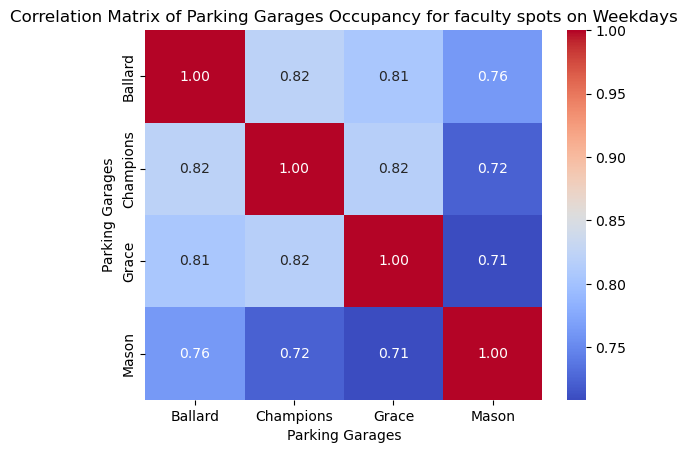

Clustered parking garages faculty Weekdays:
      Garage  Cluster
0    Ballard        1
1  Champions        1
2      Grace        2
3      Mason        0


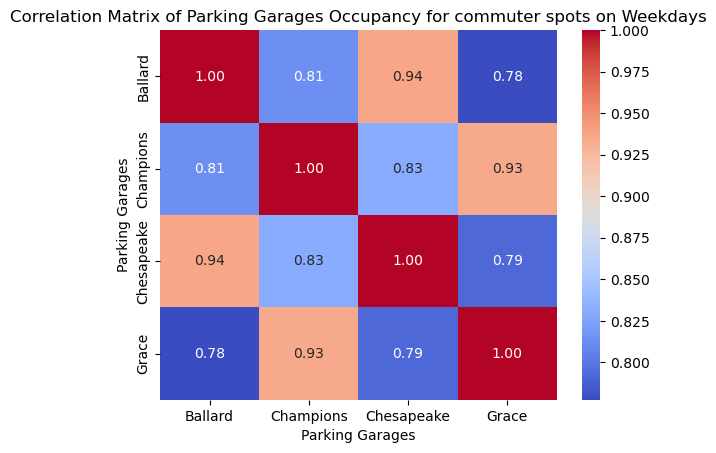

Clustered parking garages commuter Weekdays:
       Garage  Cluster
0     Ballard        2
1   Champions        1
2  Chesapeake        1
3       Grace        0


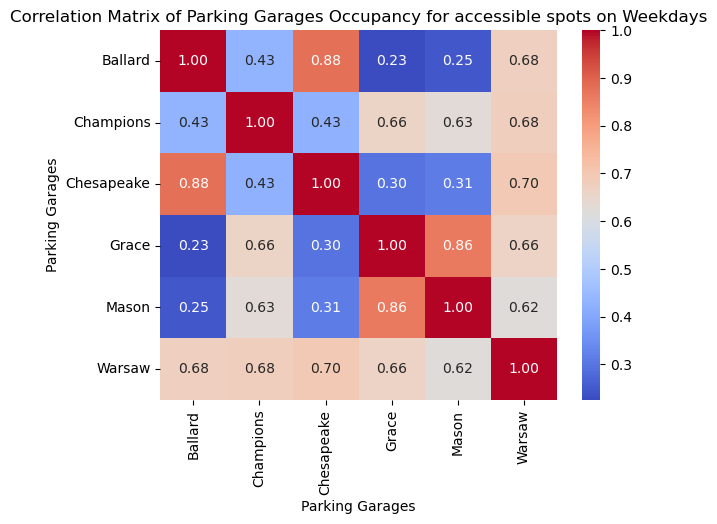

Clustered parking garages accessible Weekdays:
       Garage  Cluster
0     Ballard        1
1   Champions        2
2  Chesapeake        1
3       Grace        0
4       Mason        0
5      Warsaw        1


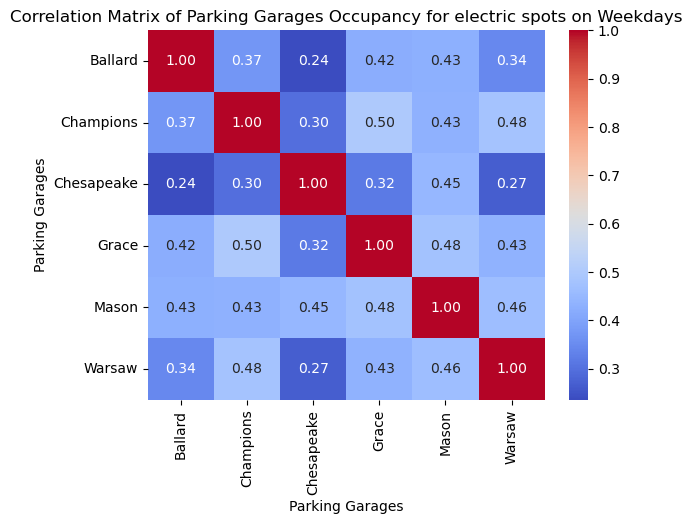

Clustered parking garages electric Weekdays:
       Garage  Cluster
0     Ballard        2
1   Champions        1
2  Chesapeake        0
3       Grace        1
4       Mason        0
5      Warsaw        1


In [8]:


for c in categ:
    ids = []
    if c == 'faculty':
        ids = ['27', '12','40', '6', '2']
    elif c == 'commuter':
        ids = ['22', '13', '19', '4', '3']
    elif c == 'electric':
        ids = ['30', '32', '34', '36', '28', '39']
    elif c == 'accessible':
        ids = ['29', '31', '33', '35', '37', '38']

    df2 = df_weekdays[df_weekdays['Zone_Id'].isin(ids)]

    # Step 1: Aggregate data
    hourly_data = df2.groupby(['Timestamp', 'Deck'])['Availability'].mean().unstack()

    # Step 2: Pivot the data
    hourly_data.reset_index(inplace=True)

    # Step 3: Calculate correlation matrix
    correlation_matrix = hourly_data.corr()

    # Step 4: Visualize the correlation matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f"Correlation Matrix of Parking Garages Occupancy for {c} spots on Weekdays")
    plt.xlabel("Parking Garages")
    plt.ylabel("Parking Garages")
    plt.savefig(f'{date_pull}/{c}.png', bbox_inches='tight')
    plt.show()

    

    # Perform spectral clustering on the correlation matrix
    n_clusters = 3  # Number of clusters
    spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed')
    cluster_labels = spectral_clustering.fit_predict(correlation_matrix)

    # Assign cluster labels to parking garages
    clustered_garages = pd.DataFrame({'Garage': correlation_matrix.columns, 'Cluster': cluster_labels})
    print(f"Clustered parking garages {c} Weekdays:")
    print(clustered_garages)

